In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)
print("Target classes:", data.target_names)

X.head()

Dataset shape: (569, 30)
Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nClass distribution:")
print(y.value_counts())

Number of samples: 569
Number of features: 30

Missing values:
0

Class distribution:
1    357
0    212
Name: count, dtype: int64


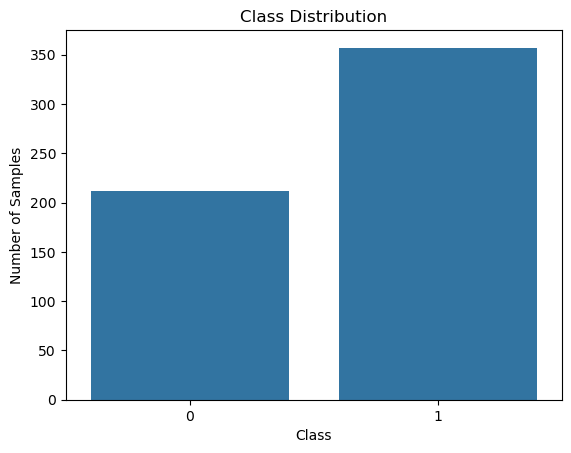

In [4]:
sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

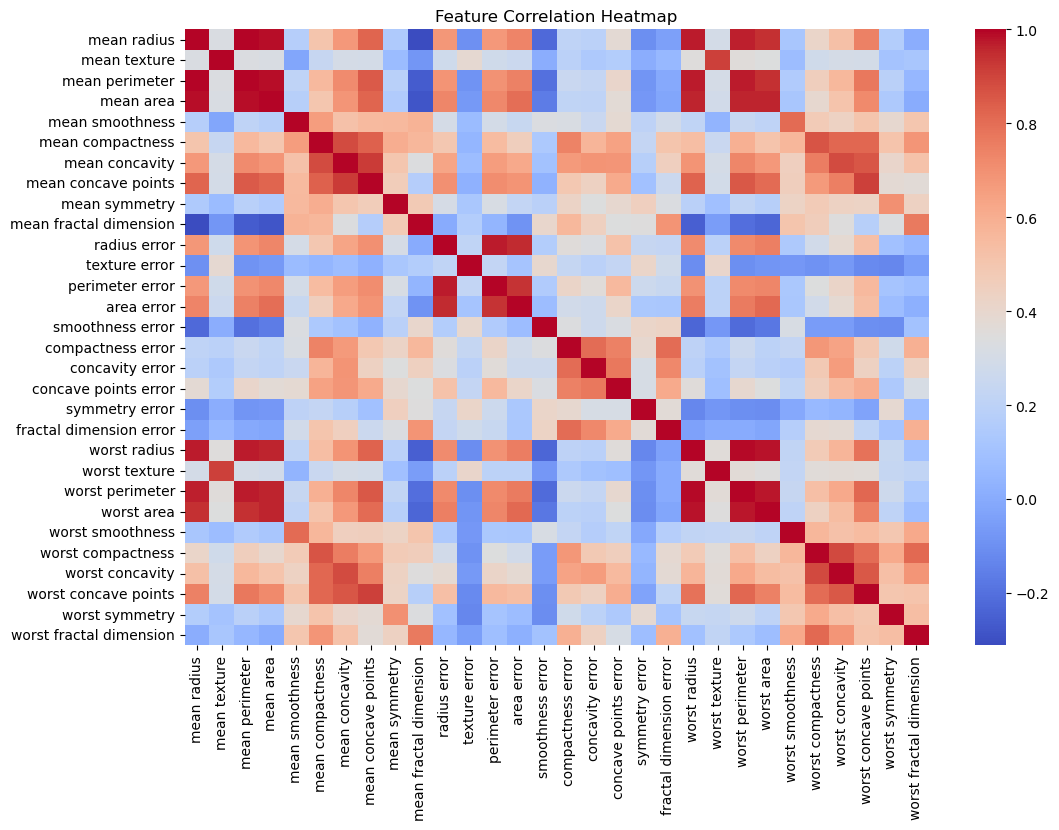

In [5]:
plt.figure(figsize=(12, 8))

sns.heatmap(X.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [8]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9122807017543859


In [10]:
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest 5-Fold CV Accuracy:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

Best 5-Fold CV Accuracy:
0.9384615384615385


In [11]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_table = dt_results[
    [
        'param_criterion',
        'param_max_depth',
        'mean_test_score'
    ]
]

dt_table = dt_table.rename(columns={
    'param_criterion': 'Criterion',
    'param_max_depth': 'Max Depth',
    'mean_test_score': 'Avg CV Accuracy'
})

dt_table['Avg CV Accuracy (%)'] = dt_table['Avg CV Accuracy'] * 100

dt_table.head(10)

,Criterion,Max Depth,Avg CV Accuracy,Avg CV Accuracy (%)
0,gini,3,0.925275,92.527473
1,gini,3,0.925275,92.527473
2,gini,3,0.925275,92.527473
3,gini,3,0.929670,92.967033
4,gini,3,0.929670,92.967033
5,gini,3,0.929670,92.967033
6,gini,3,0.927473,92.747253
7,gini,3,0.927473,92.747253
8,gini,3,0.927473,92.747253
9,gini,5,0.931868,93.186813


In [12]:
dt_grid_f1 = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

dt_grid_f1.fit(X_train, y_train)

print("Best Decision Tree F1 Score:")
print(dt_grid_f1.best_score_)

Best Decision Tree F1 Score:
0.9517702618506719


In [13]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.956140350877193


In [14]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7, None],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest 5-Fold CV Accuracy:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}

Best 5-Fold CV Accuracy:
0.9692307692307693


In [15]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

rf_table = rf_results[
    [
        'param_n_estimators',
        'param_max_depth',
        'param_max_features',
        'mean_test_score'
    ]
]

rf_table = rf_table.rename(columns={
    'param_n_estimators': 'n estimators',
    'param_max_depth': 'Max Depth',
    'param_max_features': 'Max Features',
    'mean_test_score': 'Avg CV Accuracy'
})

rf_table['Avg CV Accuracy (%)'] = rf_table['Avg CV Accuracy'] * 100

rf_table.head(10)

,n estimators,Max Depth,Max Features,Avg CV Accuracy,Avg CV Accuracy (%)
0,50,3,sqrt,0.951648,95.164835
1,100,3,sqrt,0.951648,95.164835
2,50,3,log2,0.947253,94.725275
3,100,3,log2,0.947253,94.725275
4,50,5,sqrt,0.951648,95.164835
5,100,5,sqrt,0.949451,94.945055
6,50,5,log2,0.951648,95.164835
7,100,5,log2,0.951648,95.164835
8,50,7,sqrt,0.951648,95.164835
9,100,7,sqrt,0.956044,95.604396


In [16]:
best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_scores = cross_val_score(
    best_dt, X_train, y_train,
    cv=cv,
    scoring='accuracy'
)

rf_scores = cross_val_score(
    best_rf, X_train, y_train,
    cv=cv,
    scoring='accuracy'
)

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Fold 1': [dt_scores[0], rf_scores[0]],
    'Fold 2': [dt_scores[1], rf_scores[1]],
    'Fold 3': [dt_scores[2], rf_scores[2]],
    'Fold 4': [dt_scores[3], rf_scores[3]],
    'Fold 5': [dt_scores[4], rf_scores[4]],
    'Average': [dt_scores.mean(), rf_scores.mean()]
})

comparison

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.945055,0.923077,0.912088,0.923077,0.890110,0.918681
1,Random Forest,0.956044,0.989011,0.934066,0.945055,0.978022,0.960440


In [17]:
comparison.iloc[:, 1:] = comparison.iloc[:, 1:] * 100

comparison

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,94.505495,92.307692,91.208791,92.307692,89.010989,91.868132
1,Random Forest,95.604396,98.901099,93.406593,94.505495,97.802198,96.043956


In [18]:
best_dt.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

y_pred_dt = best_dt.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [19]:
print("DECISION TREE")
print("----------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))


print("\nRANDOM FOREST")
print("----------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

DECISION TREE
----------------------
Accuracy : 0.9210526315789473
Precision: 0.9565217391304348
Recall   : 0.9166666666666666
F1 Score : 0.9361702127659575

RANDOM FOREST
----------------------
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104


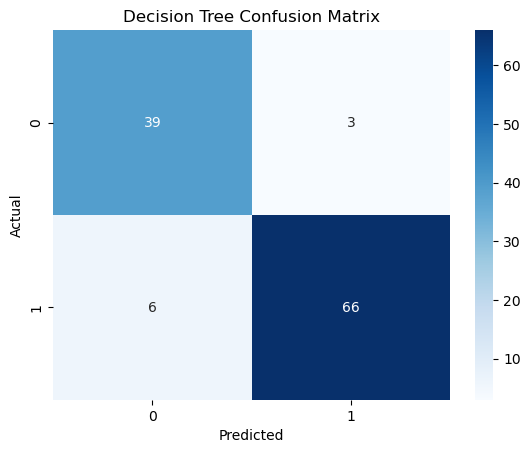

In [20]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

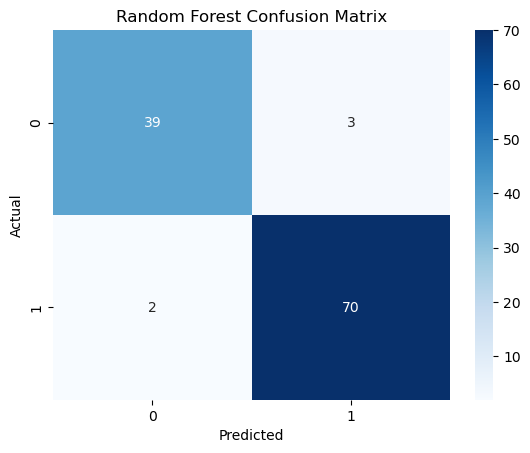

In [21]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

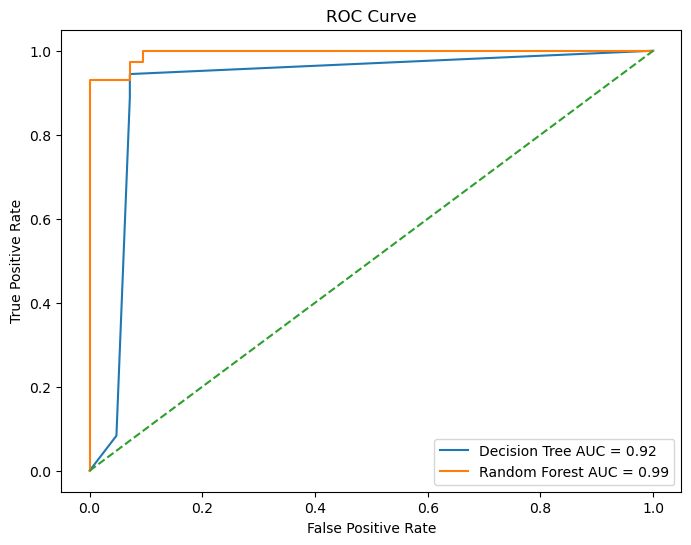

In [22]:
dt_prob = best_dt.predict_proba(X_test)[:, 1]
rf_prob = best_rf.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_dt, tpr_dt,
    label="Decision Tree AUC = {:.2f}".format(auc_dt)
)

plt.plot(
    fpr_rf, tpr_rf,
    label="Random Forest AUC = {:.2f}".format(auc_rf)
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [23]:
final_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    'AUC': [
        auc_dt,
        auc_rf
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Decision Tree,0.921053,0.956522,0.916667,0.936170,0.916336
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.994378


In [24]:
final_results.iloc[:, 1:5] = final_results.iloc[:, 1:5] * 100

final_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Decision Tree,92.105263,95.652174,91.666667,93.617021,0.916336
1,Random Forest,95.614035,95.890411,97.222222,96.551724,0.994378
